# Automated Essay Scoring

In this project, I built and compared three different approaches to automatically score student essays: a classical machine learning pipeline, a neural network (BiLSTM with attention), and a pretrained transformer (DistilBERT). The goal was to see how each approach handles the challenge of understanding writing quality, and which one came out on top.

#Whole running process takes approximately 4.5 hours

## 1. Setup & Introduction

By running the cell the dataset from Google Drive will be downloaded, so do not worry:)

In [ ]:
!gdown 1P1SwQIQuaYOrFJe7Y-vkkfuadEkQ0mw2 -O Essays.csv

Downloading...
From: https://drive.google.com/uc?id=1P1SwQIQuaYOrFJe7Y-vkkfuadEkQ0mw2
To: /content/Essays.csv
100% 36.2M/36.2M [00:00<00:00, 40.1MB/s]


I started by installing the required packages.

In [ ]:
!pip install -q lightgbm nltk wordcloud

Imported everything and set up the environment with a random seed for reproducibility.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import re
import string
import os
import ssl
import warnings
from collections import Counter
from tqdm.auto import tqdm

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import cohen_kappa_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Exploratory Data Analysis

Before building any models, I explored the dataset to understand its structure and characteristics.

In [ ]:
df = pd.read_csv('Essays.csv')
df.shape

(17307, 3)

In [ ]:
df.isnull().sum()

,0
essay_id,0
full_text,0
score,0


In [ ]:
df.score.value_counts()

,count
score,
3,6280
2,4723
4,3926
1,1252
5,970
6,156


In [ ]:
df.head()

,essay_id,full_text,score
0,000d118,Many people have car where they live. The thin...,3
1,000fe60,I am a scientist at NASA that is discussing th...,3
2,001ab80,People always wish they had the same technolog...,4
3,001bdc0,"We all heard about Venus, the planet without a...",4
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3


The dataset had 17,307 essays with three columns and no missing values. Scores ranged from 1 to 6.

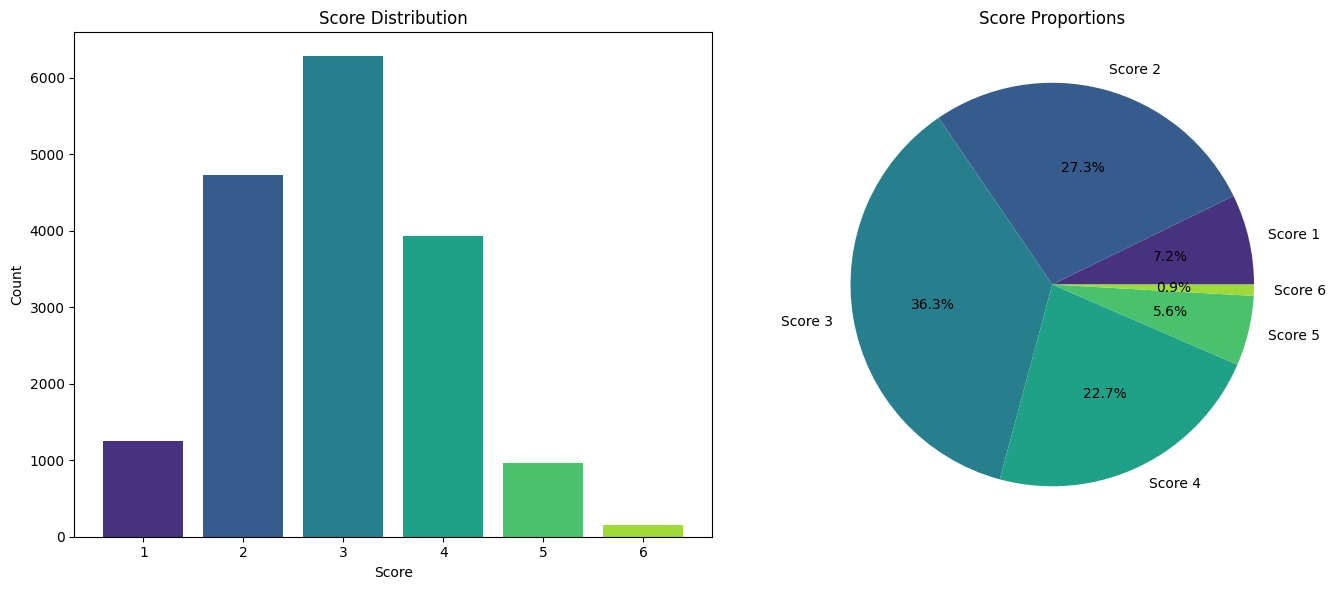

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

score_counts = df['score'].value_counts().sort_index()

colors = sns.color_palette("viridis", len(score_counts))
axes[0].bar(score_counts.index, score_counts.values, color=colors)

axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution')

axes[1].pie(score_counts.values, labels=[f"Score {s}" for s in score_counts.index],
            autopct='%1.1f%%', colors=colors)
axes[1].set_title('Score Proportions')

plt.tight_layout()
plt.show()

The distribution was clearly imbalanced. Scores 2, 3, and 4 made up roughly 86% of the data, while score 6 was extremely rare at less than 1%. This meant the models had very few examples to learn what a top-scoring essay looks like. QWK is naturally robust to class imbalance, and I used stratified splits to make sure every subset had proportional representation.

I also looked at essay lengths since intuitively, longer essays should score higher as they demonstrate more effort and development of ideas.

In [ ]:
df['char_count'] = df['full_text'].str.len()
df['word_count'] = df['full_text'].str.split().apply(len)
df['sentence_count'] = df['full_text'].apply(lambda x: len(nltk.sent_tokenize(x)))

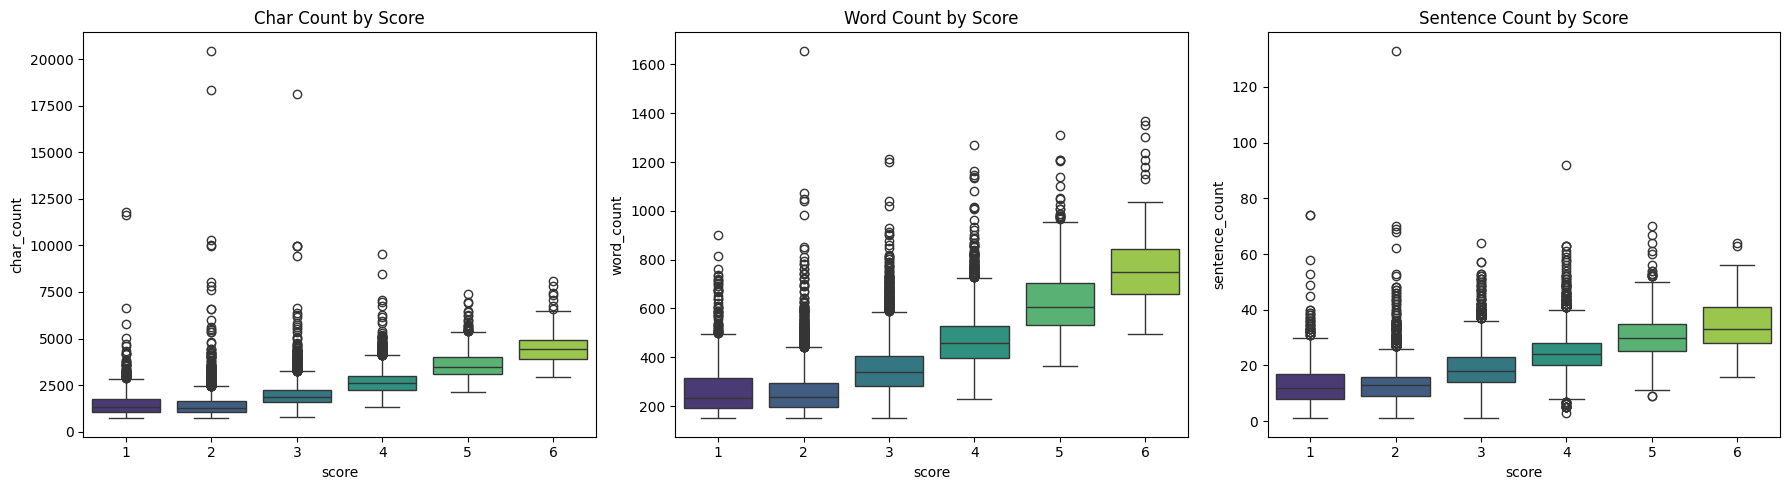

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['char_count', 'word_count', 'sentence_count']):
    sns.boxplot(x='score', y=col, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col.replace("_", " ").title()} by Score')

plt.tight_layout()
plt.show()

In [ ]:
df.groupby('score')[['word_count', 'sentence_count', 'char_count']].describe().round(1)

word_count                                                    \
           count   mean    std    min    25%    50%    75%     max   
score                                                                
1         1252.0  268.0  107.8  150.0  191.0  234.0  314.0   902.0   
2         4723.0  259.1   93.9  150.0  196.0  236.0  294.5  1656.0   
3         6280.0  353.8  100.4  152.0  284.0  339.0  405.0  1213.0   
4         3926.0  474.9  107.7  228.0  398.0  458.5  530.0  1268.0   
5          970.0  627.8  133.0  364.0  533.0  607.5  703.0  1312.0   
6          156.0  769.4  160.3  497.0  659.0  751.0  845.2  1367.0   

      sentence_count        ...              char_count                 \
               count  mean  ...   75%    max      count    mean    std   
score                       ...                                          
1             1252.0  13.2  ...  17.0   74.0     1252.0  1518.6  768.0   
2             4723.0  13.6  ...  16.0  133.0     4723.0  1444.3  705.7   
3             6280.0  18.9  ...  23.0   64.0     6280.0  1975.1  638.0   
4             3926.0  24.5  ...  28.0   92.0     3926.0  2680.9  624.7   
5              970.0  30.4  ...  35.0   70.0      970.0  3608.6  757.9   
6              156.0  34.9  ...  41.0   64.0      156.0  4500.3  927.2   

                                                
          min     25%     50%     75%      max  
score                                           
1       737.0  1044.5  1300.5  1777.2  11788.0  
2       712.0  1071.0  1292.0  1619.0  20459.0  
3       798.0  1573.0  1877.5  2250.0  18126.0  
4      1328.0  2258.0  2590.0  2998.0   9555.0  
5      2150.0  3082.8  3455.0  4009.2   7394.0  
6      2955.0  3874.8  4410.5  4935.5   8076.0  

[6 rows x 24 columns]

There was a clear trend. Higher-scoring essays tended to be longer across all three measures. The median word count jumped from around 250 for score 1 to over 500 for score 5 and 6. Students who wrote more were likely developing their arguments more fully.

I also looked at writing quality features like vocabulary diversity, word sophistication, and punctuation usage.

In [ ]:
df['unique_words'] = df['full_text'].apply(lambda x: len(set(x.lower().split())))
df['type_token_ratio'] = df['unique_words'] / df['word_count']
df['avg_word_length'] = df['full_text'].apply(lambda x: np.mean([len(w) for w in x.split()]))
df['punctuation_ratio'] = df['full_text'].apply(
    lambda x: sum(1 for c in x if c in string.punctuation) / max(len(x), 1)
)
df['paragraph_count'] = df['full_text'].apply(lambda x: len([p for p in x.split('\n\n') if p.strip()]))

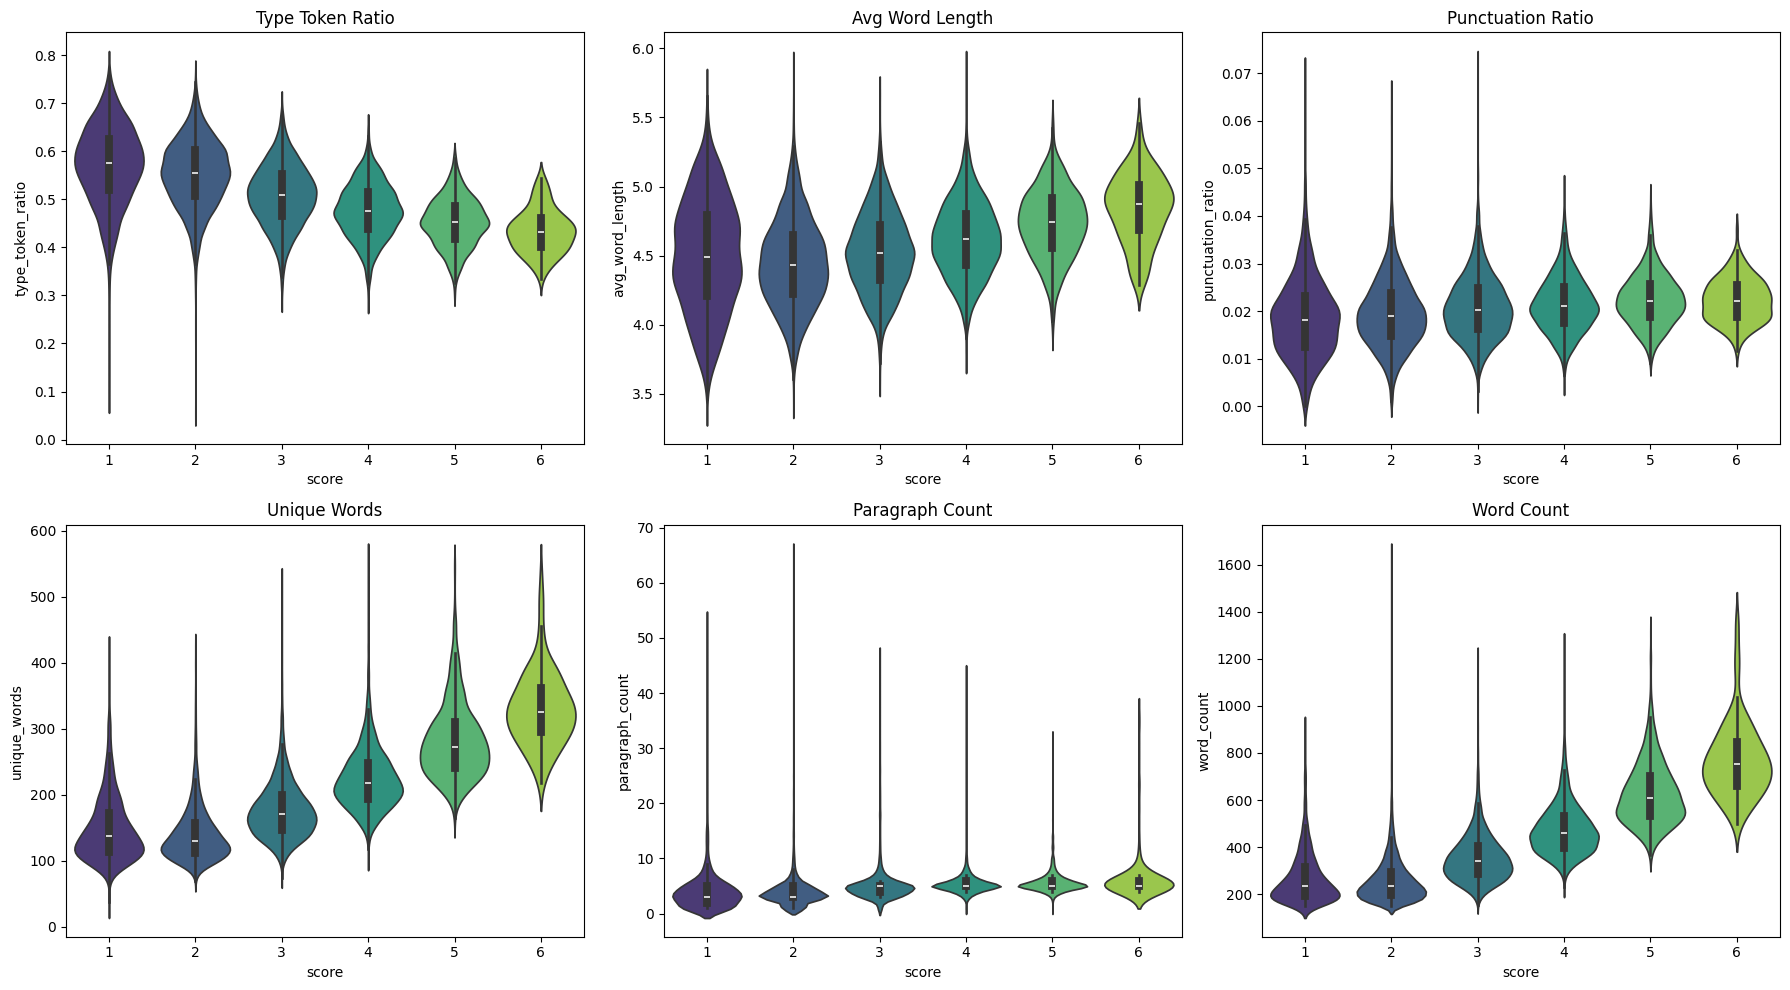

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_cols = ['type_token_ratio', 'avg_word_length', 'punctuation_ratio',
             'unique_words', 'paragraph_count', 'word_count']

for i, col in enumerate(plot_cols):
    row, col_idx = divmod(i, 3)
    sns.violinplot(x='score', y=col, data=df, ax=axes[row][col_idx], palette='viridis')
    axes[row][col_idx].set_title(col.replace('_', ' ').title())

plt.tight_layout()
plt.show()

A few interesting patterns:
- Type-token ratio actually decreased for higher scores. This seems counterintuitive, but it makes sense: longer essays naturally repeat more words, so the ratio drops even though the absolute vocabulary is richer.
- Average word length was fairly stable across scores, with a slight upward trend. Higher-scoring students used slightly longer, more sophisticated words.
- Unique words and word count both increased strongly with score, confirming the length effect.

### Topic Detection

The dataset did not include a prompt ID, so I identified topics by checking for approximate keywords in the essay text. I took topic names from the project description.

In [ ]:
def detect_topic(text):
    text_lower = text.lower()
    if 'venus' in text_lower:
        return 'Venus'
    elif 'driverless' in text_lower or 'autonomous' in text_lower:
        return 'Driverless Cars'
    elif 'electoral college' in text_lower or 'electors' in text_lower:
        return 'Electoral College'
    elif 'face on mars' in text_lower or 'cydonia' in text_lower:
        return 'Face on Mars'
    elif 'facial action' in text_lower or 'facs' in text_lower:
        return 'FACS'
    elif 'seagoing' in text_lower or 'cowboy' in text_lower:
        return 'Seagoing Cowboys'
    return 'Unknown'

df['topic_name'] = df['full_text'].apply(detect_topic)
df['topic_id'] = df['topic_name'].factorize()[0]

unmatched = (df['topic_name'] == 'Unknown').sum()
print(f"Matched: {len(df) - unmatched}, Unmatched: {unmatched}")
df['topic_name'].value_counts()

Matched: 13004, Unmatched: 4303


,count
topic_name,
Unknown,4303
Driverless Cars,3085
Venus,3018
Electoral College,1996
FACS,1741
Face on Mars,1629
Seagoing Cowboys,1535


The keywords caught most essays but not all. For the remaining ones, I computed TF-IDF vectors for each known topic cluster and assigned each unmatched essay to the closest topic.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

unmatched_mask = df['topic_name'] == 'Unknown'

if unmatched_mask.sum() > 0:
    known = df[~unmatched_mask]
    tfidf_topic = TfidfVectorizer(max_features=5000, stop_words='english')
    tfidf_topic.fit(known['full_text'])

    topic_names_list = known['topic_name'].unique()
    centroids = []
    for name in topic_names_list:
        vecs = tfidf_topic.transform(known[known['topic_name'] == name]['full_text'])
        centroids.append(np.asarray(vecs.mean(axis=0)).flatten())
    centroid_matrix = np.vstack(centroids)

    unknown_vecs = tfidf_topic.transform(df[unmatched_mask]['full_text'])
    sims = cosine_similarity(unknown_vecs, centroid_matrix)
    df.loc[unmatched_mask, 'topic_name'] = topic_names_list[sims.argmax(axis=1)]
    df['topic_id'] = df['topic_name'].factorize()[0]

df['topic_name'].value_counts()

Assigned 4303 unmatched essays via cosine similarity


,count
topic_name,
Driverless Cars,5452
FACS,3045
Venus,3024
Face on Mars,2090
Electoral College,2046
Seagoing Cowboys,1650


I also checked how scores varied across topics to see if some were inherently easier or harder to write about.

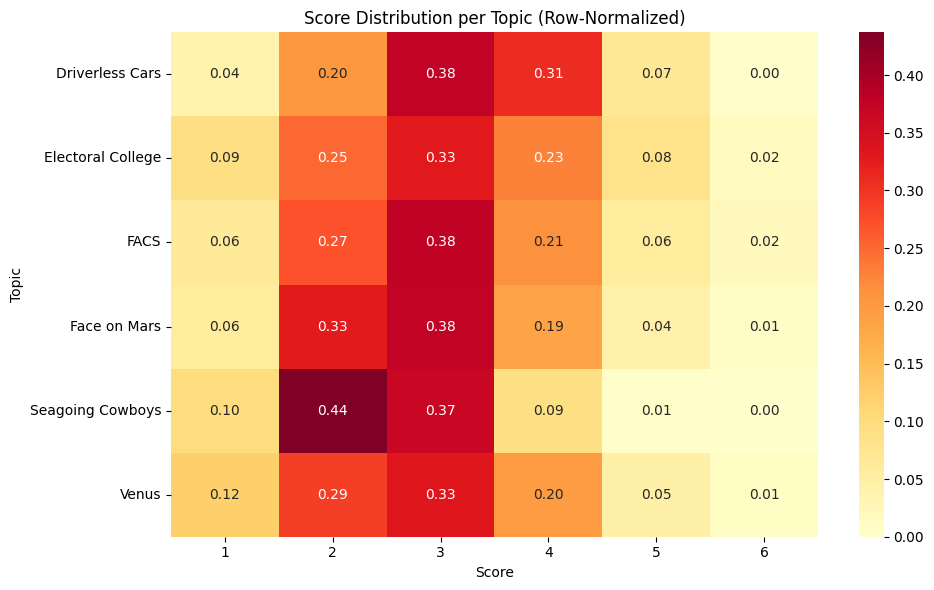

In [ ]:
ct = pd.crosstab(df['topic_name'], df['score'], normalize='index')

plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Score Distribution per Topic (Row-Normalized)')
plt.ylabel('Topic')
plt.xlabel('Score')
plt.tight_layout()
plt.show()

The heatmap showed that scoring patterns varied across topics. Some topics clustered more toward middle scores while others had a wider spread.

I also checked how well the simple shallow features correlated with the score.

In [ ]:
feature_cols = ['word_count', 'sentence_count', 'char_count', 'unique_words',
                'type_token_ratio', 'avg_word_length', 'punctuation_ratio', 'paragraph_count']

corr_with_score = df[feature_cols + ['score']].corr()['score'].drop('score').sort_values(ascending=False)
print("Pearson correlation with score:")
print(corr_with_score.round(3))

Pearson correlation with score:
word_count           0.690
char_count           0.648
unique_words         0.641
sentence_count       0.583
avg_word_length      0.247
paragraph_count      0.187
punctuation_ratio    0.148
type_token_ratio    -0.470
Name: score, dtype: float64


## 3. Data Splitting

I used a stratified 70/15/15 split to make sure:
1. The score distribution was preserved in every subset
2. The test set was completely locked away until the very end
3. No information from validation or test essays leaked into the training features

In [ ]:
df_trainval, df_test = train_test_split(
    df, test_size=0.15, random_state=SEED, stratify=df['score']
)

df_train, df_val = train_test_split(
    df_trainval, test_size=15/85, random_state=SEED, stratify=df_trainval['score']
)

print(f"Train: {len(df_train):,} ({len(df_train)/len(df)*100:.1f}%)")
print(f"Val:   {len(df_val):,} ({len(df_val)/len(df)*100:.1f}%)")
print(f"Test:  {len(df_test):,} ({len(df_test)/len(df)*100:.1f}%)")

Train: 12,114 (70.0%)
Val:   2,596 (15.0%)
Test:  2,597 (15.0%)


I verified that the stratification worked by comparing the score proportions across all three sets.

In [ ]:
split_dist = pd.DataFrame({
    'Train': df_train['score'].value_counts(normalize=True).sort_index(),
    'Val': df_val['score'].value_counts(normalize=True).sort_index(),
    'Test': df_test['score'].value_counts(normalize=True).sort_index(),
    'Full': df['score'].value_counts(normalize=True).sort_index()
}).round(3)

print("Score proportions across splits:")
print(split_dist)

Score proportions across splits:
       Train    Val   Test   Full
score                            
1      0.072  0.072  0.072  0.072
2      0.273  0.273  0.273  0.273
3      0.363  0.363  0.363  0.363
4      0.227  0.227  0.227  0.227
5      0.056  0.056  0.056  0.056
6      0.009  0.009  0.009  0.009


In [ ]:
y_train = df_train['score'].values
y_val = df_val['score'].values
y_test = df_test['score'].values

print(f"y_train shape: {y_train.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"y_test shape:  {y_test.shape}")

y_train shape: (12114,)
y_val shape:   (2596,)
y_test shape:  (2597,)


The proportions matched almost exactly across all splits, so stratification worked as intended.

## 4. Feature Engineering

For the classical ML models, I converted the raw essay text into numerical features using three groups:

1. Shallow features like word count, sentence length, vocabulary richness, punctuation usage.
2. TF-IDF word n-grams (1-2) which captured the actual words and phrases students used.
3. TF-IDF character n-grams (3-5) which captured sub-word patterns like spelling quality and morphological sophistication.

All TF-IDF vectorizers were fit only on training data to prevent any leakage.

### Shallow Features

These hand-crafted features captured writing quality signals without relying on specific word content.

In [ ]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def extract_shallow_features(texts):
    features = []
    for text in tqdm(texts, desc="Extracting shallow features"):
        words = text.split()
        sentences = nltk.sent_tokenize(text)
        unique = set(w.lower() for w in words)

        feat = {
            'word_count': len(words),
            'sentence_count': len(sentences),
            'char_count': len(text),
            'unique_word_count': len(unique),
            'type_token_ratio': len(unique) / max(len(words), 1),
            'avg_word_length': np.mean([len(w) for w in words]),
            'avg_sentence_length': np.mean([len(s.split()) for s in sentences]) if sentences else 0,
            'std_sentence_length': np.std([len(s.split()) for s in sentences]) if len(sentences) > 1 else 0,
            'punctuation_ratio': sum(1 for c in text if c in string.punctuation) / max(len(text), 1),
            'comma_count': text.count(','),
            'exclamation_count': text.count('!'),
            'question_count': text.count('?'),
            'paragraph_count': len([p for p in text.split('\n\n') if p.strip()]),
            'long_word_ratio': sum(1 for w in words if len(w) > 6) / max(len(words), 1),
            'stopword_ratio': sum(1 for w in words if w.lower() in stop_words) / max(len(words), 1),
        }
        features.append(feat)

    return pd.DataFrame(features)

In [ ]:
shallow_train = extract_shallow_features(df_train['full_text'].tolist())
shallow_val = extract_shallow_features(df_val['full_text'].tolist())
shallow_test = extract_shallow_features(df_test['full_text'].tolist())

print(f"Shallow features shape: {shallow_train.shape}")
shallow_train.head()

Extracting shallow features:   0%|          | 0/12114 [00:00<?, ?it/s]

Extracting shallow features:   0%|          | 0/2596 [00:00<?, ?it/s]

Extracting shallow features:   0%|          | 0/2597 [00:00<?, ?it/s]

Shallow features shape: (12114, 15)


,word_count,sentence_count,char_count,unique_word_count,type_token_ratio,avg_word_length,avg_sentence_length,std_sentence_length,punctuation_ratio,comma_count,exclamation_count,question_count,paragraph_count,long_word_ratio,stopword_ratio
0,320,20,1709,163,0.509375,4.325000,16.000000,7.745967,0.018139,4,2,0,3,0.153125,0.546875
1,368,14,2275,191,0.519022,5.176630,26.285714,10.726660,0.027253,18,0,0,4,0.279891,0.429348
2,268,14,1618,149,0.555970,5.000000,19.142857,3.398679,0.021632,14,1,0,3,0.264925,0.432836
3,339,29,1728,162,0.477876,4.085546,11.689655,5.439976,0.020255,4,3,0,5,0.150442,0.504425
4,213,19,1103,122,0.572770,4.169014,11.263158,7.136578,0.035358,10,0,4,4,0.136150,0.516432


### TF-IDF Word N-grams

Word unigrams and bigrams captured the actual vocabulary and phrases used. sublinear_tf=True applied log scaling so very frequent words did not dominate.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_word = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2), max_features=10000,
    min_df=5, max_df=0.95, sublinear_tf=True, strip_accents='unicode'
)

X_tfidf_word_train = tfidf_word.fit_transform(df_train['full_text'])
X_tfidf_word_val = tfidf_word.transform(df_val['full_text'])
X_tfidf_word_test = tfidf_word.transform(df_test['full_text'])

print(f"Word TF-IDF shape: {X_tfidf_word_train.shape}")

Word TF-IDF shape: (12114, 10000)


### TF-IDF Character N-grams

Character n-grams (3 to 5 characters) captured spelling patterns, morphological structure, and common word fragments. They were more robust to typos than word-level features.

In [ ]:
tfidf_char = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(3, 5), max_features=10000,
    min_df=5, max_df=0.95, sublinear_tf=True, strip_accents='unicode'
)

X_tfidf_char_train = tfidf_char.fit_transform(df_train['full_text'])
X_tfidf_char_val = tfidf_char.transform(df_val['full_text'])
X_tfidf_char_test = tfidf_char.transform(df_test['full_text'])

print(f"Char TF-IDF shape: {X_tfidf_char_train.shape}")

Char TF-IDF shape: (12114, 10000)


I stacked all three feature groups into a single feature matrix using scipy.sparse.hstack to keep things memory-efficient since the TF-IDF matrices were sparse.

In [ ]:
from scipy.sparse import hstack

X_classical_train = hstack([X_tfidf_word_train, X_tfidf_char_train, shallow_train.values]).tocsr()
X_classical_val = hstack([X_tfidf_word_val, X_tfidf_char_val, shallow_val.values]).tocsr()
X_classical_test = hstack([X_tfidf_word_test, X_tfidf_char_test, shallow_test.values]).tocsr()

print(f"Combined classical features: {X_classical_train.shape}")
print(f"Word TF-IDF:  {X_tfidf_word_train.shape[1]:,} features")
print(f"Char TF-IDF:  {X_tfidf_char_train.shape[1]:,} features")
print(f"Shallow:      {shallow_train.shape[1]:,} features")
print(f"Total:        {X_classical_train.shape[1]:,} features")

Combined classical features: (12114, 20015)
Word TF-IDF:  10,000 features
Char TF-IDF:  10,000 features
Shallow:      15 features
Total:        20,015 features


That was about 20,000 features in total. The two TF-IDF matrices dominated, but the 15 shallow features added complementary signal that pure n-grams missed (like sentence structure variability and paragraph organization).

## 5. Model A: Classical ML (Ridge Regression + LightGBM)

Before training the models, I defined the metric functions used throughout the project. The primary metric was Quadratic Weighted Kappa (QWK), which is the standard for essay scoring and measures agreement between predicted and true scores while accounting for the ordinal nature of the labels. I also tracked MAE, RMSE, and Spearman correlation as secondary metrics.

### 5a. Ridge Regression with 5-Fold CV

I used 5-fold stratified cross-validation on the training set to find the best regularization strength (alpha), trying several values.

In [ ]:
def quadratic_weighted_kappa(y_true, y_pred_continuous):
    y_pred_rounded = np.clip(np.round(y_pred_continuous), 1, 6).astype(int)
    return cohen_kappa_score(y_true, y_pred_rounded, weights='quadratic')

In [ ]:
def compute_metrics(y_true, y_pred_continuous):
    qwk = quadratic_weighted_kappa(y_true, y_pred_continuous)
    mae = mean_absolute_error(y_true, y_pred_continuous)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_continuous))
    rho, _ = spearmanr(y_true, y_pred_continuous)
    return {'QWK': qwk, 'MAE': mae, 'RMSE': rmse, 'Spearman_rho': rho}

In [ ]:
from sklearn.linear_model import Ridge

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

best_alpha = None
best_qwk = -1

for alpha in [0.1, 1.0, 10.0, 50.0, 100.0]:
    fold_qwks = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_classical_train, y_train)):
        model = Ridge(alpha=alpha)
        model.fit(X_classical_train[train_idx], y_train[train_idx])
        preds = model.predict(X_classical_train[val_idx])
        fold_qwks.append(quadratic_weighted_kappa(y_train[val_idx], preds))

    mean_qwk = np.mean(fold_qwks)
    std_qwk = np.std(fold_qwks)
    print(f"alpha={alpha:6.1f}  →  CV QWK = {mean_qwk:.4f} (± {std_qwk:.4f})")

    if mean_qwk > best_qwk:
        best_qwk = mean_qwk
        best_alpha = alpha

print(f"\nBest alpha: {best_alpha} with CV QWK: {best_qwk:.4f}")

alpha=   0.1  →  CV QWK = 0.7122 (± 0.0090)
alpha=   1.0  →  CV QWK = 0.7690 (± 0.0071)
alpha=  10.0  →  CV QWK = 0.7627 (± 0.0055)
alpha=  50.0  →  CV QWK = 0.7307 (± 0.0042)
alpha= 100.0  →  CV QWK = 0.7158 (± 0.0066)

Best alpha: 1.0 with CV QWK: 0.7690


I trained the final Ridge model with the best alpha and evaluated it on the validation set.

In [ ]:
ridge_model = Ridge(alpha=best_alpha)
ridge_model.fit(X_classical_train, y_train)

ridge_val_preds = ridge_model.predict(X_classical_val)
ridge_val_metrics = compute_metrics(y_val, ridge_val_preds)

print("Ridge Regression Validation Metrics:")
for k, v in ridge_val_metrics.items():
    print(f"  {k}: {v:.4f}")

Ridge Regression Validation Metrics:
  QWK: 0.7705
  MAE: 0.4783
  RMSE: 0.6105
  Spearman_rho: 0.8093


### 5b. LightGBM with 5-Fold CV

LightGBM can capture non-linear relationships that Ridge misses. I used 5-fold CV with early stopping to prevent overfitting, then ensembled the fold models by averaging their predictions.

In [ ]:
import lightgbm as lgb

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'n_estimators': 1000,
    'random_state': SEED,
    'verbose': -1
}

lgb_oof_preds = np.zeros(len(y_train))
lgb_models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_classical_train, y_train)):
    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(
        X_classical_train[train_idx], y_train[train_idx],
        eval_set=[(X_classical_train[val_idx], y_train[val_idx])],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
    )

    preds = model.predict(X_classical_train[val_idx])
    lgb_oof_preds[val_idx] = preds
    lgb_models.append(model)

    qwk = quadratic_weighted_kappa(y_train[val_idx], preds)
    print(f"Fold {fold+1}: QWK = {qwk:.4f} (best_iteration = {model.best_iteration_})")

oof_qwk = quadratic_weighted_kappa(y_train, lgb_oof_preds)
print(f"\nLightGBM OOF QWK: {oof_qwk:.4f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[203]	valid_0's rmse: 0.582643
Fold 1: QWK = 0.7744 (best_iteration = 203)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[381]	valid_0's rmse: 0.57757
Fold 2: QWK = 0.7824 (best_iteration = 381)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[182]	valid_0's rmse: 0.585106
Fold 3: QWK = 0.7790 (best_iteration = 182)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[205]	valid_0's rmse: 0.573645
Fold 4: QWK = 0.7824 (best_iteration = 205)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[215]	valid_0's rmse: 0.597336
Fold 5: QWK = 0.7667 (best_iteration = 215)

LightGBM OOF QWK: 0.7770


In [ ]:
lgb_val_preds = np.mean([m.predict(X_classical_val) for m in lgb_models], axis=0)
lgb_val_metrics = compute_metrics(y_val, lgb_val_preds)

print("LightGBM Validation Metrics:")
for k, v in lgb_val_metrics.items():
    print(f"  {k}: {v:.4f}")

LightGBM Validation Metrics:
  QWK: 0.7778
  MAE: 0.4507
  RMSE: 0.5818
  Spearman_rho: 0.8288


One of the biggest advantages of classical models is interpretability. I examined which features the Ridge model considered most important and what LightGBM split on most.

In [ ]:
word_feature_names = tfidf_word.get_feature_names_out()
char_feature_names = tfidf_char.get_feature_names_out()
shallow_feature_names = list(shallow_train.columns)
all_feature_names = np.concatenate([word_feature_names, char_feature_names, shallow_feature_names])

Ridge coefficients: positive coefficients pushed the score up, negative coefficients pushed it down.

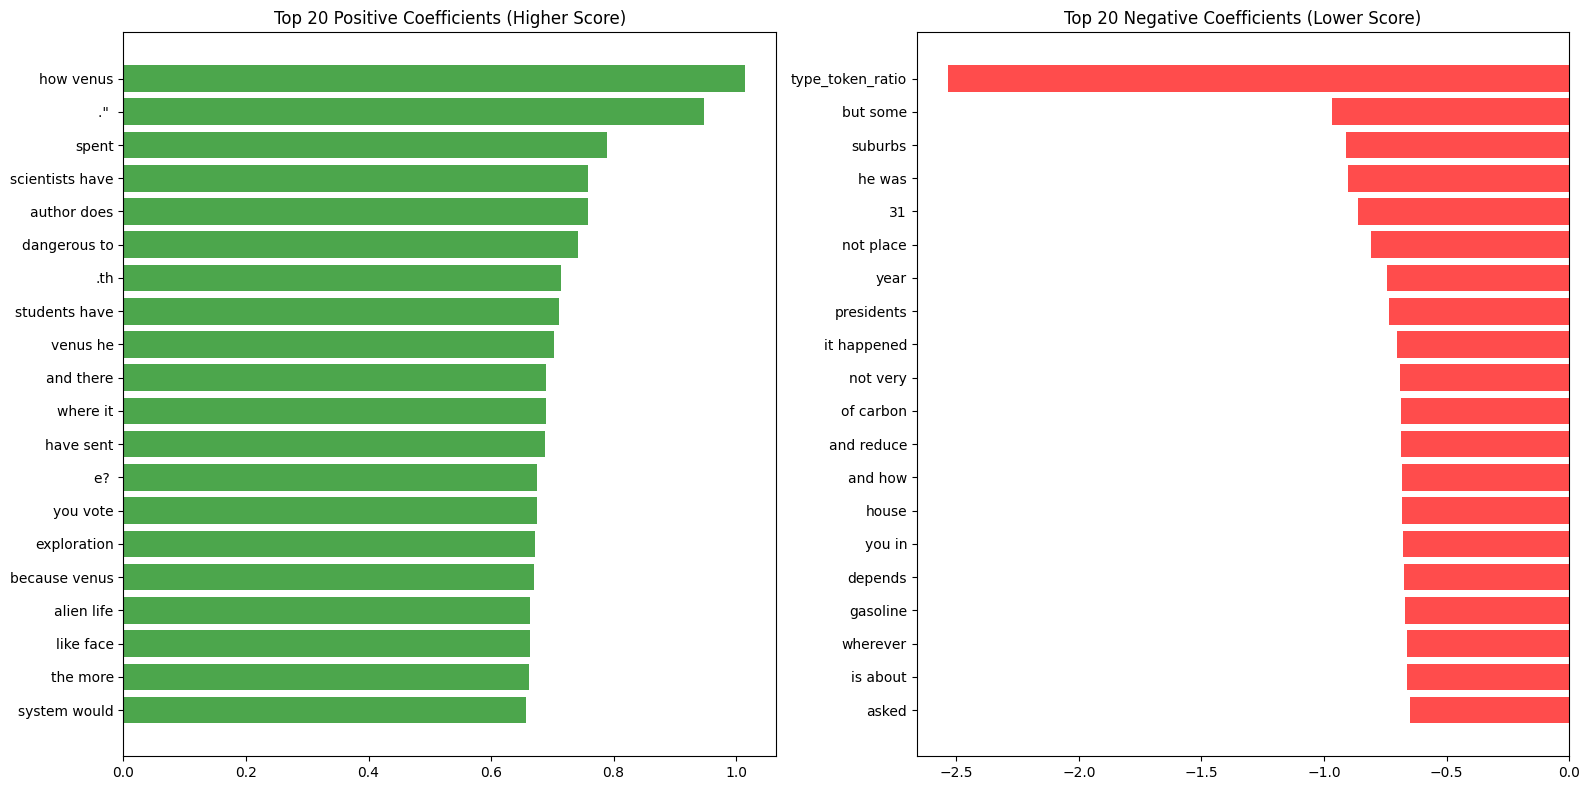

In [ ]:
coefs = ridge_model.coef_
top_pos_idx = np.argsort(coefs)[-20:][::-1]
top_neg_idx = np.argsort(coefs)[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(range(20), coefs[top_pos_idx], color='green', alpha=0.7)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(all_feature_names[top_pos_idx])
axes[0].set_title('Top 20 Positive Coefficients (Higher Score)')
axes[0].invert_yaxis()

axes[1].barh(range(20), coefs[top_neg_idx], color='red', alpha=0.7)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(all_feature_names[top_neg_idx])
axes[1].set_title('Top 20 Negative Coefficients (Lower Score)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

LightGBM feature importance: how often each feature was used for splitting decisions across all trees.

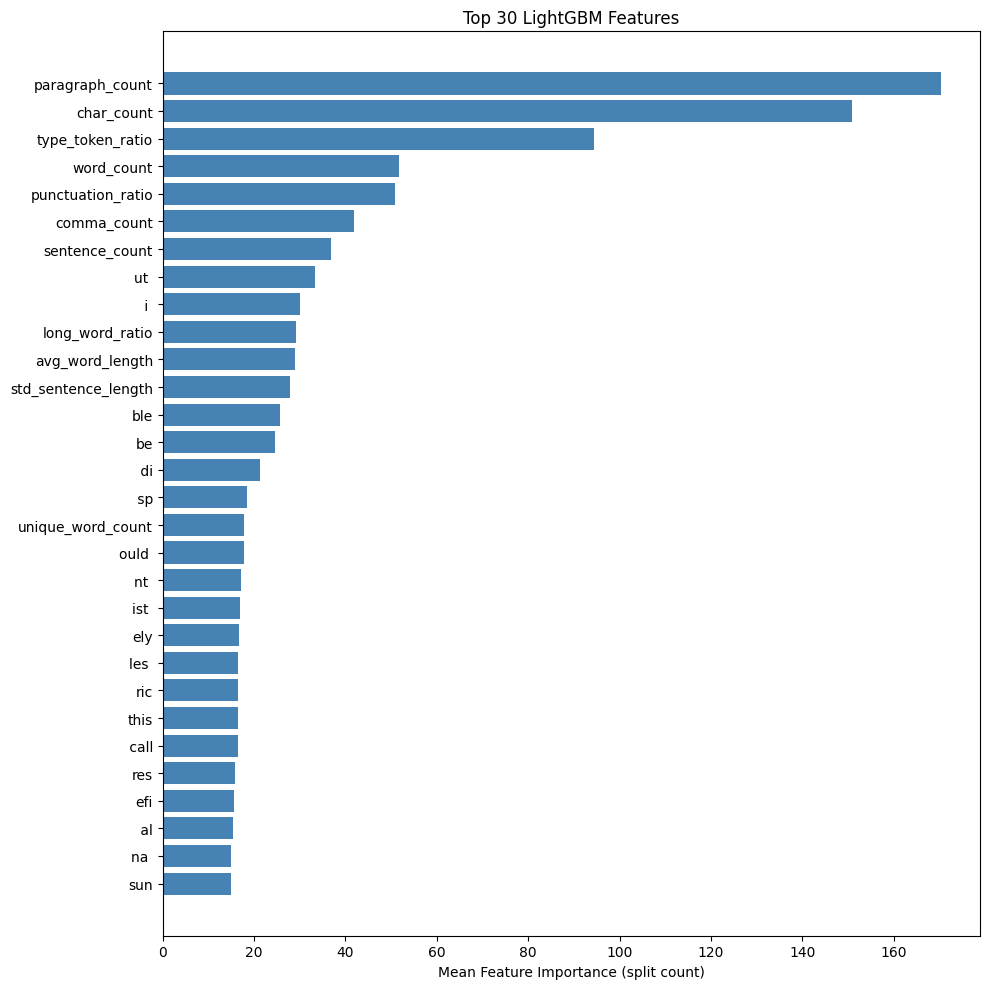

In [ ]:
importances = np.mean([m.feature_importances_ for m in lgb_models], axis=0)
top_feat_idx = np.argsort(importances)[-30:]

plt.figure(figsize=(10, 10))
plt.barh(range(30), importances[top_feat_idx], color='steelblue')
plt.yticks(range(30), all_feature_names[top_feat_idx])
plt.xlabel('Mean Feature Importance (split count)')
plt.title('Top 30 LightGBM Features')
plt.tight_layout()
plt.show()

### Feature Ablation

I measured how much each feature group contributed by training Ridge on different subsets.

In [ ]:
feature_groups = {
    'TF-IDF Word only': (X_tfidf_word_train, X_tfidf_word_val),
    'TF-IDF Char only': (X_tfidf_char_train, X_tfidf_char_val),
    'Shallow only': (shallow_train.values, shallow_val.values),
    'Word + Char': (hstack([X_tfidf_word_train, X_tfidf_char_train]).tocsr(),
                    hstack([X_tfidf_word_val, X_tfidf_char_val]).tocsr()),
    'All Combined': (X_classical_train, X_classical_val),
}

ablation_results = {}
for name, (X_tr, X_va) in feature_groups.items():
    model = Ridge(alpha=best_alpha)
    model.fit(X_tr, y_train)
    preds = model.predict(X_va)
    metrics = compute_metrics(y_val, preds)
    ablation_results[name] = metrics

TF-IDF Word only     | QWK: 0.7360 | MAE: 0.4966 | Spearman: 0.7957
TF-IDF Char only     | QWK: 0.7491 | MAE: 0.4939 | Spearman: 0.7964
Shallow only         | QWK: 0.6785 | MAE: 0.5389 | Spearman: 0.7460
Word + Char          | QWK: 0.7652 | MAE: 0.4884 | Spearman: 0.8002
All Combined         | QWK: 0.7705 | MAE: 0.4783 | Spearman: 0.8093


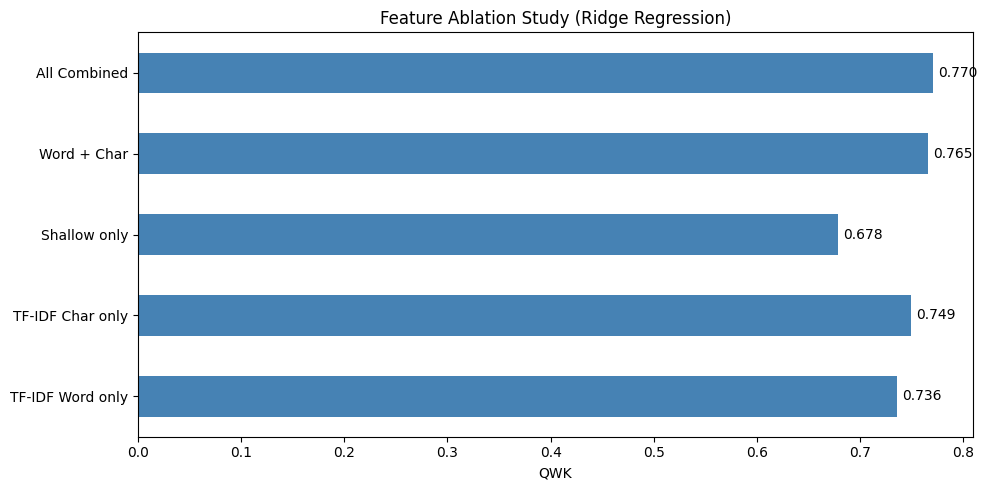

In [ ]:
ablation_df = pd.DataFrame(ablation_results).T

fig, ax = plt.subplots(figsize=(10, 5))
ablation_df['QWK'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('QWK')
ax.set_title('Feature Ablation Study (Ridge Regression)')
for i, v in enumerate(ablation_df['QWK']):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

- Word TF-IDF alone was the strongest individual group. The specific words and phrases a student used were the most informative signal.
- Character n-grams added complementary value. Combining word and char TF-IDF improved over either alone.
- Shallow features alone were weaker but still useful. They captured structural aspects that n-grams missed.
- All combined gave the best result, confirming that each feature group contributed non-redundant information.

## 6. Model B: BiLSTM with Attention

For the neural approach, instead of relying on hand-crafted features, I used a bidirectional LSTM to learn representations from word embeddings, with a self-attention layer so the model could focus on the most important parts of each essay.

GloVe (Global Vectors) provides pretrained word embeddings trained on 6 billion tokens from Wikipedia and Gigaword. I used the 100-dimensional version since it was a good balance between richness and training speed. With only around 12K training essays, learning word embeddings from scratch would have been ineffective, so GloVe gave a good start for me.

In [ ]:
import urllib.request
import zipfile

glove_path = 'glove.6B.100d.txt'

if not os.path.exists(glove_path):
    url = 'https://nlp.stanford.edu/data/glove.6B.zip'
    zip_path = 'glove.6B.zip'
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=ctx))
    urllib.request.install_opener(opener)
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extract('glove.6B.100d.txt')
    os.remove(zip_path)
    print("Done!")
else:
    print(f"GloVe file already exists: {glove_path}")

Done!


I loaded the GloVe vectors into a dictionary and built a vocabulary from the training data, only including words that appeared at least twice since rare words were likely noise or typos.

In [ ]:
glove_embeddings = {}
with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        word = parts[0]
        vector = np.array(parts[1:], dtype=np.float32)
        glove_embeddings[word] = vector

print(f"Loaded {len(glove_embeddings):,} GloVe vectors (dim={len(next(iter(glove_embeddings.values())))})")

Loaded 400,000 GloVe vectors (dim=100)


In [ ]:
MIN_FREQ = 2
word_counter = Counter()
for text in df_train['full_text']:
    word_counter.update(text.lower().split())

word2idx = {'<PAD>': 0, '<UNK>': 1}
idx = 2
for word, count in word_counter.items():
    if count >= MIN_FREQ:
        word2idx[word] = idx
        idx += 1

VOCAB_SIZE = len(word2idx)
EMBED_DIM = 100
print(f"Vocabulary size: {VOCAB_SIZE:,}")

covered = sum(1 for w in word2idx if w in glove_embeddings)
print(f"GloVe coverage: {covered}/{VOCAB_SIZE} ({covered/VOCAB_SIZE*100:.1f}%)")

Vocabulary size: 37,843
GloVe coverage: 13314/37843 (35.2%)


In [ ]:
embedding_matrix = np.random.uniform(-0.25, 0.25, (VOCAB_SIZE, EMBED_DIM)).astype(np.float32)
embedding_matrix[0] = np.zeros(EMBED_DIM)

for word, i in word2idx.items():
    if word in glove_embeddings:
        embedding_matrix[i] = glove_embeddings[word]

print(f"Embedding matrix shape: {embedding_matrix.shape}")

Embedding matrix shape: (37843, 100)


Then I created a PyTorch Dataset that tokenized each essay, mapped words to vocabulary indices, and padded/truncated to a fixed length of 512 tokens, which was long enough to capture most essays.

In [ ]:
from torch.utils.data import Dataset, DataLoader

MAX_LEN = 512

class EssayDataset(Dataset):
    def __init__(self, texts, scores, word2idx, max_len=MAX_LEN):
        self.texts = texts
        self.scores = scores
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        words = self.texts[idx].lower().split()[:self.max_len]
        ids = [self.word2idx.get(w, 1) for w in words]
        length = len(ids)
        ids += [0] * (self.max_len - length)

        return {
            'input_ids': torch.tensor(ids, dtype=torch.long),
            'length': torch.tensor(length, dtype=torch.long),
            'score': torch.tensor(self.scores[idx], dtype=torch.float)
        }

BATCH_SIZE = 32

train_dataset = EssayDataset(df_train['full_text'].tolist(), y_train, word2idx)
val_dataset = EssayDataset(df_val['full_text'].tolist(), y_val, word2idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 379, Val batches: 82


The architecture had four main parts:
- Embedding layer which converted word IDs to 100d GloVe vectors
- BiLSTM that read the essay forward and backward, producing a 256d hidden state at each position
- Self-attention that learned which positions were most important and produced a weighted average
- Dense head that mapped the attended representation to a single score

In [ ]:
class BiLSTMAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, embedding_matrix):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(torch.FloatTensor(embedding_matrix))
        self.embedding.weight.requires_grad = False

        self.dropout = nn.Dropout(0.3)

        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers,
            bidirectional=True, batch_first=True, dropout=0.3
        )

        self.attention = nn.Linear(hidden_dim * 2, 1)

        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, input_ids, lengths):
        x = self.dropout(self.embedding(input_ids))

        lstm_out, _ = self.lstm(x)

        mask = (input_ids != 0).unsqueeze(-1).float()
        attn_scores = self.attention(lstm_out)
        attn_scores = attn_scores.masked_fill(mask == 0, float('-inf'))
        attn_weights = F.softmax(attn_scores, dim=1)

        context = (lstm_out * attn_weights).sum(dim=1)

        out = F.relu(self.fc1(self.dropout(context)))
        out = self.fc2(self.dropout(out))
        return out.squeeze(-1), attn_weights.squeeze(-1)

HIDDEN_DIM = 128
NUM_LAYERS = 2

bilstm_model = BiLSTMAttention(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, embedding_matrix)
bilstm_model = bilstm_model.to(DEVICE)

total_params = sum(p.numel() for p in bilstm_model.parameters())
trainable_params = sum(p.numel() for p in bilstm_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen (GloVe embeddings): {total_params - trainable_params:,}")

Total parameters: 4,431,854
Trainable parameters: 647,554
Frozen (GloVe embeddings): 3,784,300


I trained with MSE loss, Adam optimizer, learning rate scheduling, and early stopping.

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, bilstm_model.parameters()), lr=1e-3
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

MAX_EPOCHS = 30
PATIENCE = 5
CLIP_NORM = 1.0

best_val_qwk = -1
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_qwk': []}

for epoch in range(MAX_EPOCHS):
    bilstm_model.train()
    train_losses = []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS}", leave=False):
        input_ids = batch['input_ids'].to(DEVICE)
        lengths = batch['length'].to(DEVICE)
        scores = batch['score'].to(DEVICE)

        optimizer.zero_grad()
        preds, _ = bilstm_model(input_ids, lengths)
        loss = criterion(preds, scores)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bilstm_model.parameters(), CLIP_NORM)
        optimizer.step()
        train_losses.append(loss.item())

    avg_train_loss = np.mean(train_losses)

    bilstm_model.eval()
    val_losses = []
    all_preds, all_targets = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            lengths = batch['length'].to(DEVICE)
            scores = batch['score'].to(DEVICE)

            preds, _ = bilstm_model(input_ids, lengths)
            val_losses.append(criterion(preds, scores).item())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(scores.cpu().numpy())

    avg_val_loss = np.mean(val_losses)
    val_preds_np = np.array(all_preds)
    val_targets_np = np.array(all_targets)
    val_qwk = quadratic_weighted_kappa(val_targets_np, val_preds_np)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_qwk'].append(val_qwk)

    print(f"Epoch {epoch+1:2d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val QWK: {val_qwk:.4f}")

    scheduler.step(val_qwk)

    if val_qwk > best_val_qwk:
        best_val_qwk = val_qwk
        patience_counter = 0
        torch.save(bilstm_model.state_dict(), 'best_bilstm.pt')
        print(f"  New best! Saved checkpoint.")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping after {epoch+1} epochs.")
            break

print(f"\nBest validation QWK: {best_val_qwk:.4f}")

Epoch 1/30:   0%|          | 0/379 [00:00<?, ?it/s]

Epoch  1 | Train Loss: 1.0992 | Val Loss: 0.5287 | Val QWK: 0.6349
  New best! Saved checkpoint.


Epoch 2/30:   0%|          | 0/379 [00:00<?, ?it/s]

Epoch  2 | Train Loss: 0.7103 | Val Loss: 0.4708 | Val QWK: 0.6947
  New best! Saved checkpoint.


Epoch 3/30:   0%|          | 0/379 [00:00<?, ?it/s]

...

Epoch 23 | Train Loss: 0.3872 | Val Loss: 0.3840 | Val QWK: 0.7791


Epoch 24/30:   0%|          | 0/379 [00:00<?, ?it/s]

Epoch 24 | Train Loss: 0.3812 | Val Loss: 0.3732 | Val QWK: 0.7704


Epoch 25/30:   0%|          | 0/379 [00:00<?, ?it/s]

Epoch 25 | Train Loss: 0.3763 | Val Loss: 0.3841 | Val QWK: 0.7615
  Early stopping after 25 epochs.

Best validation QWK: 0.7792


Training progress - loss curves and QWK over epochs.

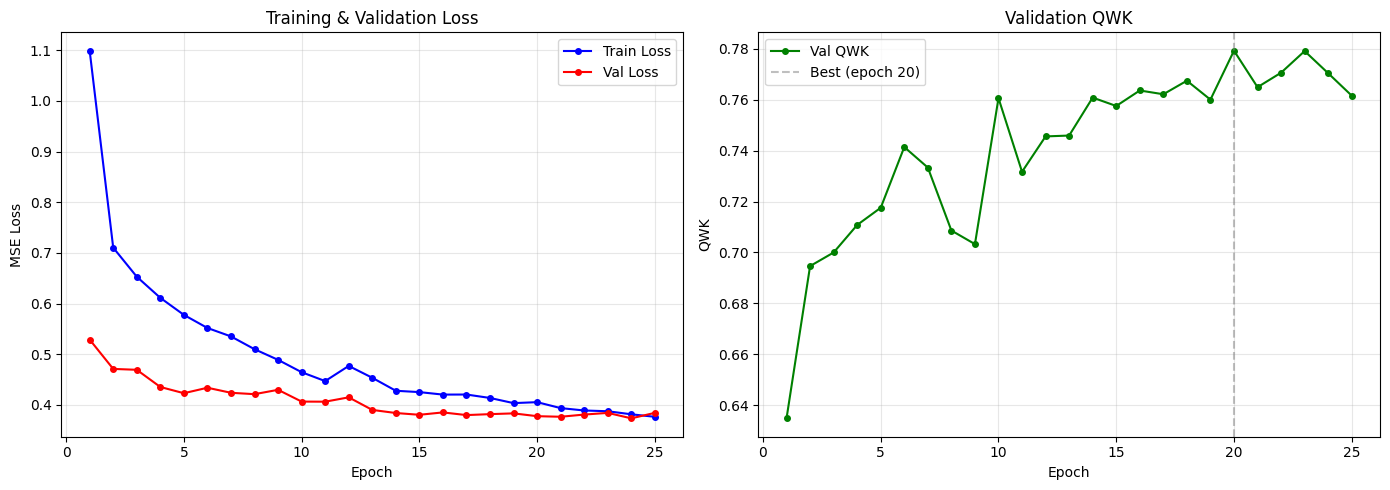

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs_range, history['val_loss'], 'r-o', label='Val Loss', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['val_qwk'], 'g-o', label='Val QWK', markersize=4)
best_epoch = np.argmax(history['val_qwk']) + 1
axes[1].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('QWK')
axes[1].set_title('Validation QWK')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The best checkpoint and final validation metrics:

In [ ]:
bilstm_model.load_state_dict(torch.load('best_bilstm.pt', map_location=DEVICE))
bilstm_model.eval()

bilstm_val_preds = []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        lengths = batch['length'].to(DEVICE)
        preds, _ = bilstm_model(input_ids, lengths)
        bilstm_val_preds.extend(preds.cpu().numpy())

bilstm_val_preds = np.array(bilstm_val_preds)
bilstm_val_metrics = compute_metrics(y_val, bilstm_val_preds)

for k, v in bilstm_val_metrics.items():
    print(f"  {k}: {v:.4f}")

  QWK: 0.7792
  MAE: 0.4719
  RMSE: 0.6142
  Spearman_rho: 0.8160


I examined the attention weights to see which words the model focused on when scoring essays, picking a few samples and visualizing their attention patterns.

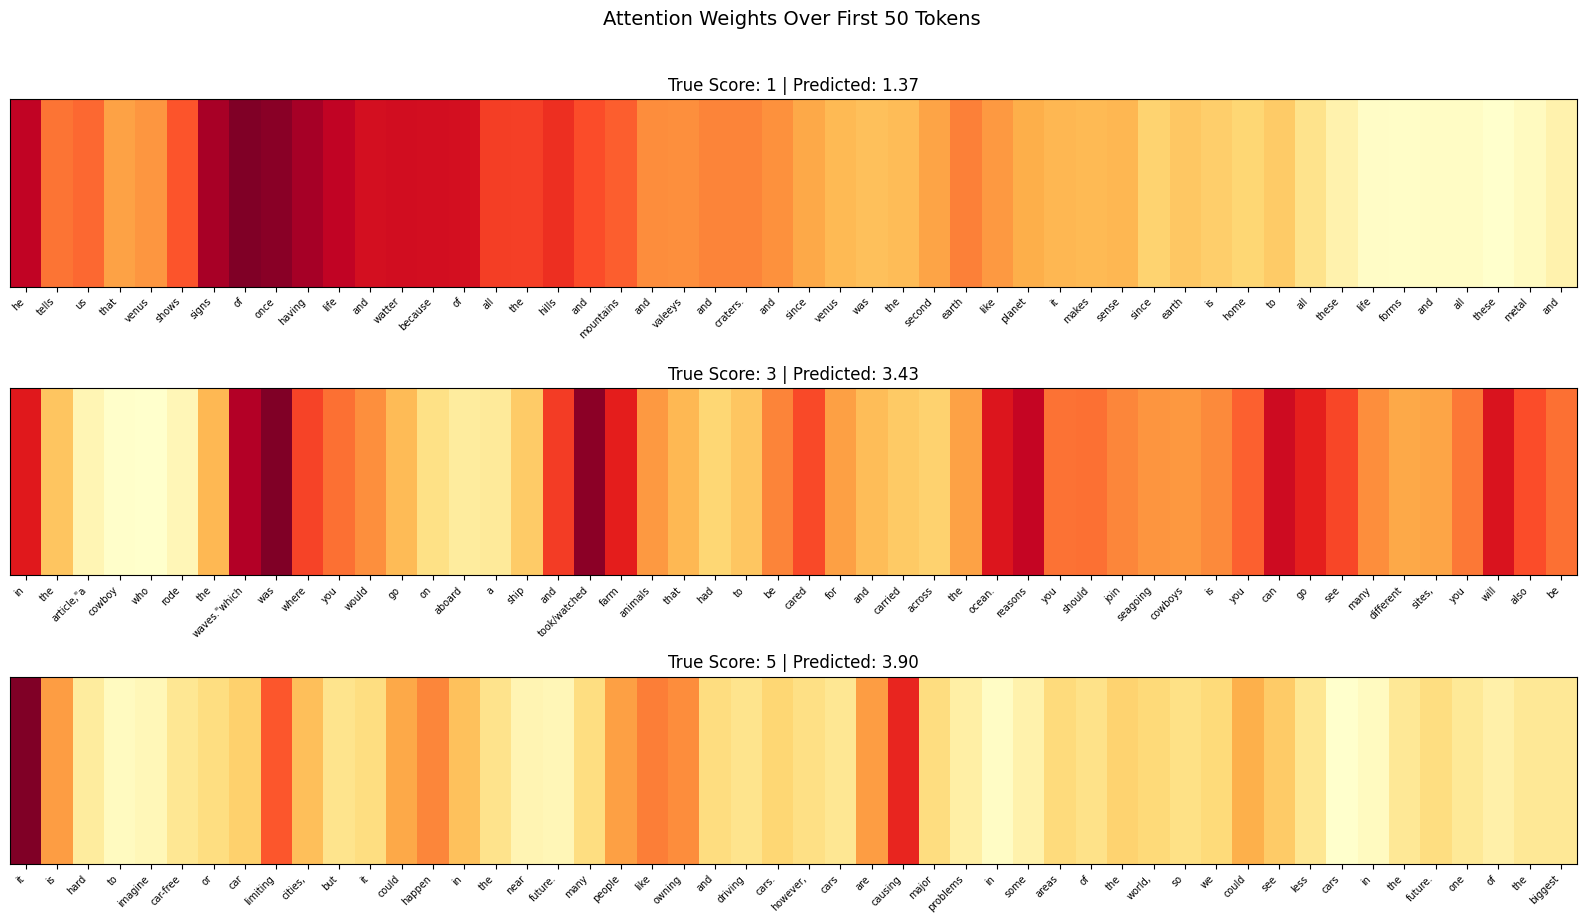

In [ ]:
idx2word = {v: k for k, v in word2idx.items()}

def visualize_attention(model, text, word2idx, idx2word, max_tokens=50):
    model.eval()
    words = text.lower().split()[:MAX_LEN]
    ids = [word2idx.get(w, 1) for w in words]
    length = len(ids)
    ids_padded = ids + [0] * (MAX_LEN - length)

    input_tensor = torch.tensor([ids_padded], dtype=torch.long).to(DEVICE)
    length_tensor = torch.tensor([length], dtype=torch.long).to(DEVICE)

    with torch.no_grad():
        pred, attn = model(input_tensor, length_tensor)

    attn = attn[0, :length].cpu().numpy()
    display_words = words[:max_tokens]
    display_attn = attn[:max_tokens]

    return pred.item(), display_words, display_attn

sample_indices = []
for target_score in [1, 3, 5]:
    matches = df_val[df_val['score'] == target_score].index
    if len(matches) > 0:
        sample_indices.append(matches[0])

fig, axes = plt.subplots(len(sample_indices), 1, figsize=(16, 3 * len(sample_indices)))

for i, idx in enumerate(sample_indices):
    text = df_val.loc[idx, 'full_text']
    true_score = df_val.loc[idx, 'score']
    pred_score, words, attn = visualize_attention(bilstm_model, text, word2idx, idx2word)

    attn_2d = attn.reshape(1, -1)
    axes[i].imshow(attn_2d, cmap='YlOrRd', aspect='auto')
    axes[i].set_xticks(range(len(words)))
    axes[i].set_xticklabels(words, rotation=45, ha='right', fontsize=7)
    axes[i].set_yticks([])
    axes[i].set_title(f"True Score: {true_score} | Predicted: {pred_score:.2f}")

plt.suptitle('Attention Weights Over First 50 Tokens', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The top-attended tokens across multiple validation essays:

In [ ]:
word_attention_scores = Counter()
n_samples = min(200, len(df_val))
sample_val = df_val.sample(n=n_samples, random_state=SEED)

for _, row in sample_val.iterrows():
    _, words, attn = visualize_attention(bilstm_model, row['full_text'], word2idx, idx2word, max_tokens=MAX_LEN)
    for w, a in zip(words, attn):
        if w not in ['<PAD>', '<UNK>'] and len(w) > 2:
            word_attention_scores[w] += a

top_attended = word_attention_scores.most_common(15)
print("Top 15 Most-Attended Words (aggregated across 200 val essays):")
for word, score in top_attended:
    print(f"  {word:20s} cumulative attention: {score:.4f}")

Top 15 Most-Attended Words (aggregated across 200 val essays):
  the                  cumulative attention: 10.1783
  that                 cumulative attention: 3.9182
  and                  cumulative attention: 3.9132
  would                cumulative attention: 2.2473
  you                  cumulative attention: 2.2010
  they                 cumulative attention: 1.8837
  are                  cumulative attention: 1.8508
  this                 cumulative attention: 1.7414
  not                  cumulative attention: 1.6974
  can                  cumulative attention: 1.5364
  for                  cumulative attention: 1.4779
  have                 cumulative attention: 1.4767
  people               cumulative attention: 1.2922
  venus                cumulative attention: 1.2857
  could                cumulative attention: 1.2415


## 7. Model C: DistilBERT with Regression Head

DistilBERT is a distilled version of BERT that retains 97% of BERT's language understanding while being 40% smaller and 60% faster. Unlike the BiLSTM which started from static GloVe vectors, DistilBERT came with contextualized embeddings where the same word got different representations depending on its context.

###  Model Setup

In [ ]:
from transformers import DistilBertModel, DistilBertTokenizer

class DistilBERTRegressor(nn.Module):
    def __init__(self, model_name='distilbert-base-uncased', freeze_layers=4):
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained(model_name)

        for param in self.distilbert.embeddings.parameters():
            param.requires_grad = False

        for i in range(freeze_layers):
            for param in self.distilbert.transformer.layer[i].parameters():
                param.requires_grad = False

        self.dropout = nn.Dropout(0.2)
        self.regressor = nn.Linear(768, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)
        logits = self.regressor(cls_output)
        return logits.squeeze(-1)

bert_model = DistilBERTRegressor(freeze_layers=4).to(DEVICE)

total_params = sum(p.numel() for p in bert_model.parameters())
trainable_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")
print(f"Trainable ratio:      {trainable_params/total_params*100:.1f}%")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters:     66,363,649
Trainable parameters: 14,176,513
Frozen parameters:    52,187,136
Trainable ratio:      21.4%


### Data Preparation

DistilBERT has its own tokenizer that handles subword splitting, special tokens ([CLS], [SEP]), and attention masks automatically. I used HuggingFace's tokenizer with max_length=512.

In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class BertEssayDataset(Dataset):
    def __init__(self, texts, scores, tokenizer, max_length=512):
        self.texts = texts
        self.scores = scores
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'score': torch.tensor(self.scores[idx], dtype=torch.float)
        }

BERT_BATCH_SIZE = 16

bert_train_dataset = BertEssayDataset(df_train['full_text'].tolist(), y_train, tokenizer)
bert_val_dataset = BertEssayDataset(df_val['full_text'].tolist(), y_val, tokenizer)

bert_train_loader = DataLoader(bert_train_dataset, batch_size=BERT_BATCH_SIZE, shuffle=True)
bert_val_loader = DataLoader(bert_val_dataset, batch_size=BERT_BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(bert_train_loader)}, Val batches: {len(bert_val_loader)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Train batches: 758, Val batches: 163


Fine-tuning transformers requires care. That is why I used layer-wise learning rate decay so that lower transformer layers (which encode general linguistic knowledge) got smaller learning rates, while higher layers (which are more task-specific) and the classification head got larger ones. This prevented overwriting the useful pretrained knowledge in the lower layers.

In [ ]:
from transformers import get_linear_schedule_with_warmup

BASE_LR = 2e-5
LR_DECAY = 0.9
HEAD_LR_MULT = 10

param_groups = []

for layer_idx in range(4, 6):
    layer_lr = BASE_LR * (LR_DECAY ** (5 - layer_idx))
    params = list(bert_model.distilbert.transformer.layer[layer_idx].parameters())
    param_groups.append({'params': params, 'lr': layer_lr})
    print(f"  Layer {layer_idx}: lr = {layer_lr:.2e} ({len(params)} param tensors)")

head_params = list(bert_model.regressor.parameters())
head_lr = BASE_LR * HEAD_LR_MULT
param_groups.append({'params': head_params, 'lr': head_lr})
print(f"  Head:    lr = {head_lr:.2e} ({len(head_params)} param tensors)")

bert_optimizer = torch.optim.AdamW(param_groups, weight_decay=0.01)

BERT_EPOCHS = 5
total_steps = len(bert_train_loader) * BERT_EPOCHS
warmup_steps = int(0.1 * total_steps)

bert_scheduler = get_linear_schedule_with_warmup(
    bert_optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

print(f"\nTotal training steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")

  Layer 4: lr = 1.80e-05 (16 param tensors)
  Layer 5: lr = 2.00e-05 (16 param tensors)
  Head:    lr = 2.00e-04 (2 param tensors)

Total training steps: 3790
Warmup steps: 379


In [ ]:
bert_criterion = nn.MSELoss()
bert_history = {'train_loss': [], 'val_loss': [], 'val_qwk': []}
best_bert_qwk = -1

for epoch in range(BERT_EPOCHS):
    bert_model.train()
    train_losses = []

    for batch in tqdm(bert_train_loader, desc=f"Epoch {epoch+1}/{BERT_EPOCHS}", leave=False):
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        scores = batch['score'].to(DEVICE)

        bert_optimizer.zero_grad()
        preds = bert_model(input_ids, attention_mask)
        loss = bert_criterion(preds, scores)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        bert_optimizer.step()
        bert_scheduler.step()
        train_losses.append(loss.item())

    avg_train_loss = np.mean(train_losses)

    bert_model.eval()
    val_losses = []
    all_preds, all_targets = [], []

    with torch.no_grad():
        for batch in bert_val_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            scores = batch['score'].to(DEVICE)

            preds = bert_model(input_ids, attention_mask)
            val_losses.append(bert_criterion(preds, scores).item())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(scores.cpu().numpy())

    avg_val_loss = np.mean(val_losses)
    val_qwk = quadratic_weighted_kappa(np.array(all_targets), np.array(all_preds))

    bert_history['train_loss'].append(avg_train_loss)
    bert_history['val_loss'].append(avg_val_loss)
    bert_history['val_qwk'].append(val_qwk)

    current_lr = bert_scheduler.get_last_lr()[0]
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val QWK: {val_qwk:.4f} | LR: {current_lr:.2e}")

    if val_qwk > best_bert_qwk:
        best_bert_qwk = val_qwk
        torch.save(bert_model.state_dict(), 'best_distilbert.pt')
        print(f"  New best! Saved checkpoint.")

print(f"\nBest validation QWK: {best_bert_qwk:.4f}")

Epoch 1/5:   0%|          | 0/758 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 1.3324 | Val Loss: 0.4256 | Val QWK: 0.7187 | LR: 1.60e-05
  New best! Saved checkpoint.


Epoch 2/5:   0%|          | 0/758 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 0.4201 | Val Loss: 0.4214 | Val QWK: 0.7550 | LR: 1.20e-05
  New best! Saved checkpoint.


Epoch 3/5:   0%|          | 0/758 [00:00<?, ?it/s]

Epoch 3 | Train Loss: 0.3759 | Val Loss: 0.3789 | Val QWK: 0.7606 | LR: 8.00e-06
  New best! Saved checkpoint.


Epoch 4/5:   0%|          | 0/758 [00:00<?, ?it/s]

Epoch 4 | Train Loss: 0.3490 | Val Loss: 0.3712 | Val QWK: 0.7654 | LR: 4.00e-06
  New best! Saved checkpoint.


Epoch 5/5:   0%|          | 0/758 [00:00<?, ?it/s]

Epoch 5 | Train Loss: 0.3284 | Val Loss: 0.3681 | Val QWK: 0.7733 | LR: 0.00e+00
  New best! Saved checkpoint.

Best validation QWK: 0.7733


In [ ]:
bert_model.load_state_dict(torch.load('best_distilbert.pt', map_location=DEVICE))
bert_model.eval()

bert_val_preds = []
with torch.no_grad():
    for batch in bert_val_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        preds = bert_model(input_ids, attention_mask)
        bert_val_preds.extend(preds.cpu().numpy())

bert_val_preds = np.array(bert_val_preds)
bert_val_metrics = compute_metrics(y_val, bert_val_preds)

print("DistilBERT Validation Metrics (Best Checkpoint):")
for k, v in bert_val_metrics.items():
    print(f"  {k}: {v:.4f}")

DistilBERT Validation Metrics (Best Checkpoint):
  QWK: 0.7733
  MAE: 0.4714
  RMSE: 0.6065
  Spearman_rho: 0.8238


I used gradient-based token attribution to understand what DistilBERT was looking at. The idea was to compute the gradient of the predicted score with respect to each input embedding, then take the L2 norm at each token position. Tokens with large gradient norms had a bigger influence on the prediction.

In [ ]:
def get_token_attributions(model, text, tokenizer, device):
    model.eval()
    model.zero_grad()

    encoding = tokenizer(
        text, truncation=True, max_length=512,
        padding='max_length', return_tensors='pt'
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    embedding_output = {}

    def hook_fn(module, input, output):
        out = output.detach().requires_grad_(True)
        embedding_output['value'] = out
        return out

    handle = model.distilbert.embeddings.register_forward_hook(hook_fn)

    pred = model(input_ids, attention_mask)
    pred.backward()

    handle.remove()

    grads = embedding_output['value'].grad[0]
    token_importance = grads.norm(dim=-1).detach().cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu())
    seq_len = int(attention_mask[0].sum().item())

    return pred.item(), tokens[:seq_len], token_importance[:seq_len]

for target_score in [2, 4, 5]:
    matches = df_val[df_val['score'] == target_score]
    if len(matches) == 0:
        continue
    row = matches.iloc[0]

    pred, tokens, importances = get_token_attributions(bert_model, row['full_text'], tokenizer, DEVICE)

    top_idx = np.argsort(importances)[-15:][::-1]

    print()
    print(f"True Score: {target_score} | Predicted: {pred:.2f}")
    print("Top 15 most influential tokens:")
    for i, idx in enumerate(top_idx):
        print(f"  {i+1:2d}. {tokens[idx]:15s} (importance: {importances[idx]:.4f})")


True Score: 2 | Predicted: 2.21
Top 15 most influential tokens:
   1. [CLS]           (importance: 0.0502)
   2. disagree        (importance: 0.0204)
   3. paragraph       (importance: 0.0197)
   4. mars            (importance: 0.0189)
   5. paragraph       (importance: 0.0184)
   6. [SEP]           (importance: 0.0174)
   7. talked          (importance: 0.0167)
   8. illusions       (importance: 0.0161)
   9. ##rley          (importance: 0.0157)
  10. icon            (importance: 0.0152)
  11. saying          (importance: 0.0150)
  12. .               (importance: 0.0149)
  13. ##ical          (importance: 0.0147)
  14. know            (importance: 0.0144)
  15. aliens          (importance: 0.0140)

True Score: 4 | Predicted: 3.25
Top 15 most influential tokens:
   1. [CLS]           (importance: 0.0716)
   2. reel            (importance: 0.0336)
   3. could           (importance: 0.0302)
   4. mentioning      (importance: 0.0286)
   5. this            (importance: 0.0256)
   6. .   

Then evaluated the trained model at different max token lengths to see how much of the essay DistilBERT actually needed.

max_length= 64 | QWK: -0.0006 | MAE: 1.9098
max_length=128 | QWK: 0.0713 | MAE: 1.5313
max_length=256 | QWK: 0.2527 | MAE: 0.8851
max_length=384 | QWK: 0.5878 | MAE: 0.5795
max_length=512 | QWK: 0.7733 | MAE: 0.4714


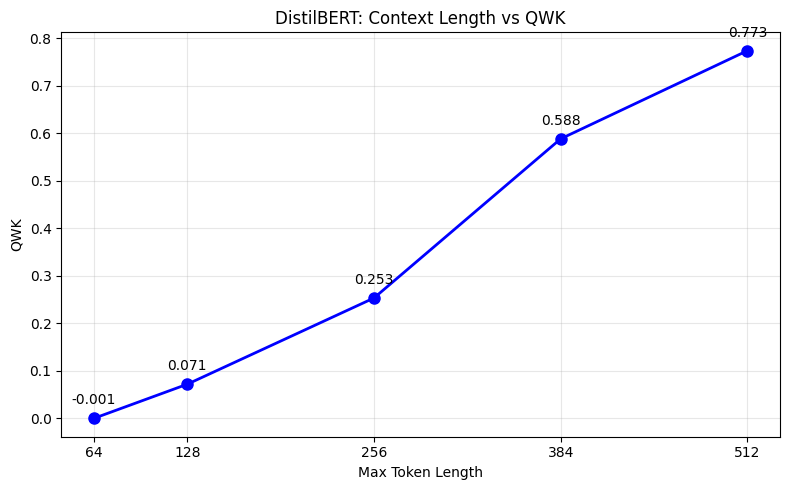

In [ ]:
context_lengths = [64, 128, 256, 384, 512]
context_results = {}

for max_len in context_lengths:
    temp_dataset = BertEssayDataset(df_val['full_text'].tolist(), y_val, tokenizer, max_length=max_len)
    temp_loader = DataLoader(temp_dataset, batch_size=BERT_BATCH_SIZE, shuffle=False)

    preds = []
    bert_model.eval()
    with torch.no_grad():
        for batch in temp_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            p = bert_model(input_ids, attention_mask)
            preds.extend(p.cpu().numpy())

    metrics = compute_metrics(y_val, np.array(preds))
    context_results[max_len] = metrics
    print(f"max_length={max_len:3d} | QWK: {metrics['QWK']:.4f} | MAE: {metrics['MAE']:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
lengths = list(context_results.keys())
qwks = [context_results[l]['QWK'] for l in lengths]

ax.plot(lengths, qwks, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Max Token Length')
ax.set_ylabel('QWK')
ax.set_title('DistilBERT: Context Length vs QWK')
ax.set_xticks(lengths)
ax.grid(True, alpha=0.3)

for l, q in zip(lengths, qwks):
    ax.annotate(f'{q:.3f}', (l, q), textcoords="offset points", xytext=(0, 10), ha='center')

plt.tight_layout()
plt.show()

## Data-Size Learning Curves

I trained Ridge and LightGBM on increasing fractions of the training data (10%, 25%, 50%, 75%, 100%) to see how performance scaled.

In [ ]:
fractions = [0.10, 0.25, 0.50, 0.75, 1.00]
ridge_curve = []
lgb_curve = []

for frac in fractions:
    n_samples = int(len(y_train) * frac)

    if frac < 1.0:
        _, sub_idx = train_test_split(
            np.arange(len(y_train)), test_size=frac,
            random_state=SEED, stratify=y_train
        )
    else:
        sub_idx = np.arange(len(y_train))

    X_sub = X_classical_train[sub_idx]
    y_sub = y_train[sub_idx]

    ridge_sub = Ridge(alpha=best_alpha)
    ridge_sub.fit(X_sub, y_sub)
    ridge_preds = ridge_sub.predict(X_classical_val)
    ridge_qwk = quadratic_weighted_kappa(y_val, ridge_preds)
    ridge_curve.append(ridge_qwk)

    lgb_sub = lgb.LGBMRegressor(**lgb_params)
    lgb_sub.fit(X_sub, y_sub, eval_set=[(X_classical_val, y_val)],
                callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    lgb_preds = lgb_sub.predict(X_classical_val)
    lgb_qwk = quadratic_weighted_kappa(y_val, lgb_preds)
    lgb_curve.append(lgb_qwk)

    print(f"Fraction: {frac:.0%} ({len(sub_idx):,} samples) | Ridge QWK: {ridge_qwk:.4f} | LightGBM QWK: {lgb_qwk:.4f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[405]	valid_0's rmse: 0.659159
Fraction: 10% (1,212 samples) | Ridge QWK: 0.7483 | LightGBM QWK: 0.7210
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[401]	valid_0's rmse: 0.628433
Fraction: 25% (3,029 samples) | Ridge QWK: 0.7623 | LightGBM QWK: 0.7406
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[399]	valid_0's rmse: 0.602422
Fraction: 50% (6,057 samples) | Ridge QWK: 0.7655 | LightGBM QWK: 0.7587
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[293]	valid_0's rmse: 0.58355
Fraction: 75% (9,086 samples) | Ridge QWK: 0.7671 | LightGBM QWK: 0.7762
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[249]	valid_0's rmse: 0.583914
Fraction: 100% (12,114 samples) | Ridge QWK: 0.7705 | LightGBM QWK: 0.7829

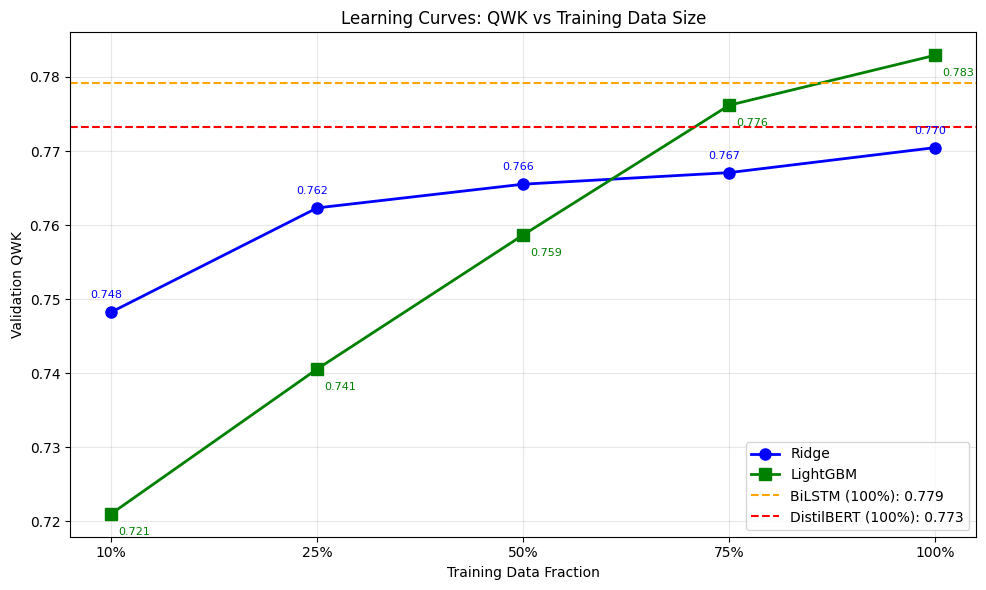

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

pct_labels = [f"{int(f*100)}%" for f in fractions]

ax.plot(pct_labels, ridge_curve, 'b-o', label='Ridge', linewidth=2, markersize=8)
ax.plot(pct_labels, lgb_curve, 'g-s', label='LightGBM', linewidth=2, markersize=8)

ax.axhline(y=bilstm_val_metrics['QWK'], color='orange', linestyle='--', linewidth=1.5,
           label=f"BiLSTM (100%): {bilstm_val_metrics['QWK']:.3f}")
ax.axhline(y=bert_val_metrics['QWK'], color='red', linestyle='--', linewidth=1.5,
           label=f"DistilBERT (100%): {bert_val_metrics['QWK']:.3f}")

ax.set_xlabel('Training Data Fraction')
ax.set_ylabel('Validation QWK')
ax.set_title('Learning Curves: QWK vs Training Data Size')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

for i, (rq, lq) in enumerate(zip(ridge_curve, lgb_curve)):
    ax.annotate(f'{rq:.3f}', (i, rq), textcoords="offset points", xytext=(-15, 10), fontsize=8, color='blue')
    ax.annotate(f'{lq:.3f}', (i, lq), textcoords="offset points", xytext=(5, -15), fontsize=8, color='green')

plt.tight_layout()
plt.show()

## 9. Evaluation


I generated test predictions from all four models.

In [ ]:
ridge_test_preds = ridge_model.predict(X_classical_test)

lgb_test_preds = np.mean([m.predict(X_classical_test) for m in lgb_models], axis=0)

test_dataset_lstm = EssayDataset(df_test['full_text'].tolist(), y_test, word2idx)
test_loader_lstm = DataLoader(test_dataset_lstm, batch_size=BATCH_SIZE, shuffle=False)

bilstm_model.eval()
bilstm_test_preds = []
with torch.no_grad():
    for batch in test_loader_lstm:
        input_ids = batch['input_ids'].to(DEVICE)
        lengths = batch['length'].to(DEVICE)
        preds, _ = bilstm_model(input_ids, lengths)
        bilstm_test_preds.extend(preds.cpu().numpy())
bilstm_test_preds = np.array(bilstm_test_preds)

test_dataset_bert = BertEssayDataset(df_test['full_text'].tolist(), y_test, tokenizer)
test_loader_bert = DataLoader(test_dataset_bert, batch_size=BERT_BATCH_SIZE, shuffle=False)

bert_model.eval()
bert_test_preds = []
with torch.no_grad():
    for batch in test_loader_bert:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        preds = bert_model(input_ids, attention_mask)
        bert_test_preds.extend(preds.cpu().numpy())
bert_test_preds = np.array(bert_test_preds)

Test predictions generated for all 4 models.


### Summary Table

In [ ]:
all_test_preds = {
    'Ridge': ridge_test_preds,
    'LightGBM': lgb_test_preds,
    'BiLSTM': bilstm_test_preds,
    'DistilBERT': bert_test_preds,
}

results = {}
for name, preds in all_test_preds.items():
    results[name] = compute_metrics(y_test, preds)

results_df = pd.DataFrame(results).T
results_df = results_df[['QWK', 'MAE', 'RMSE', 'Spearman_rho']]

results_df.round(4)

,QWK,MAE,RMSE,Spearman_rho
Ridge,0.7710,0.4786,0.6030,0.8097
LightGBM,0.7699,0.4522,0.5797,0.8288
BiLSTM,0.7716,0.4832,0.6208,0.8091
DistilBERT,0.7765,0.4682,0.5983,0.8223


### Bar Chart Comparison

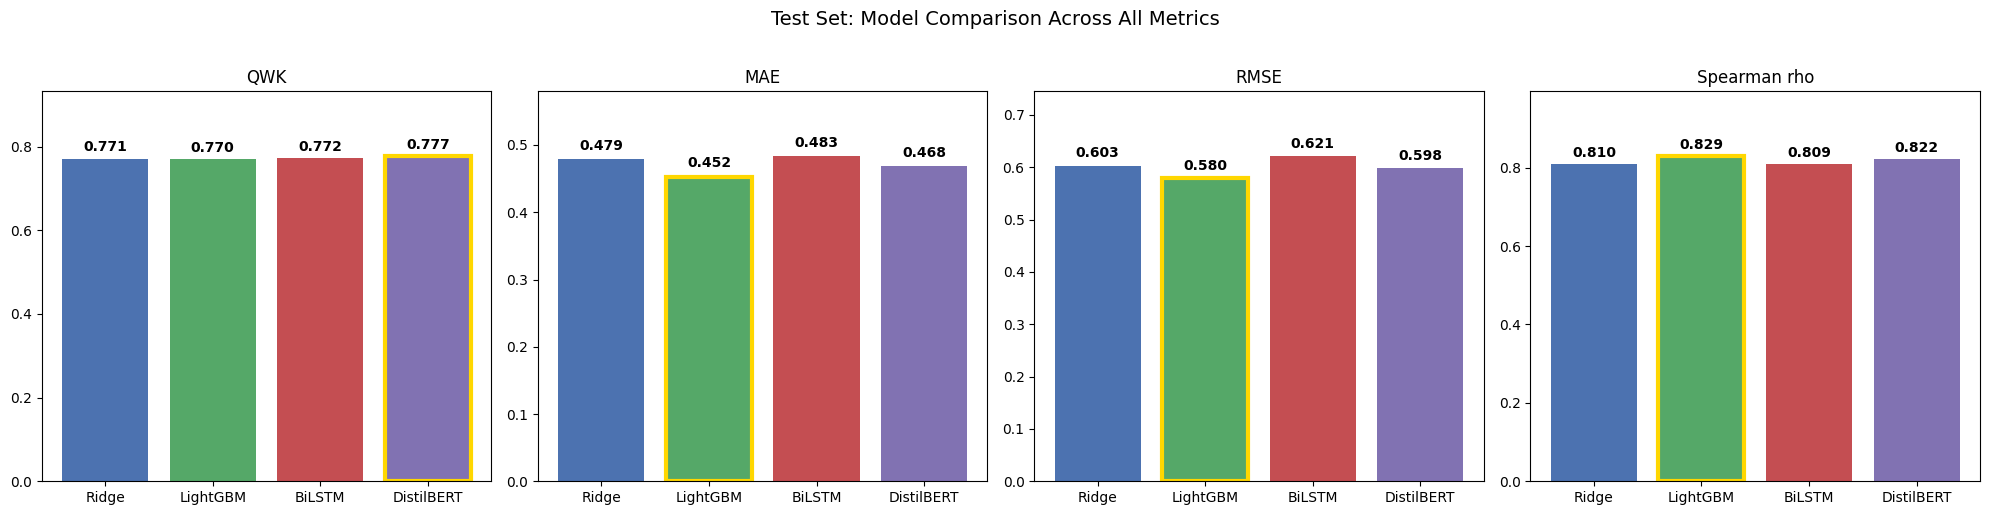

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

model_names = list(results.keys())
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for i, metric in enumerate(['QWK', 'MAE', 'RMSE', 'Spearman_rho']):
    values = [results[m][metric] for m in model_names]
    bars = axes[i].bar(model_names, values, color=colors)
    axes[i].set_title(metric.replace('_', ' '))
    axes[i].set_ylim(0, max(values) * 1.2)

    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    if metric in ['MAE', 'RMSE']:
        best_idx = np.argmin(values)
    else:
        best_idx = np.argmax(values)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

plt.suptitle('Test Set: Model Comparison Across All Metrics', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Confusion Matrices

The confusion matrices showed where each model got confused.

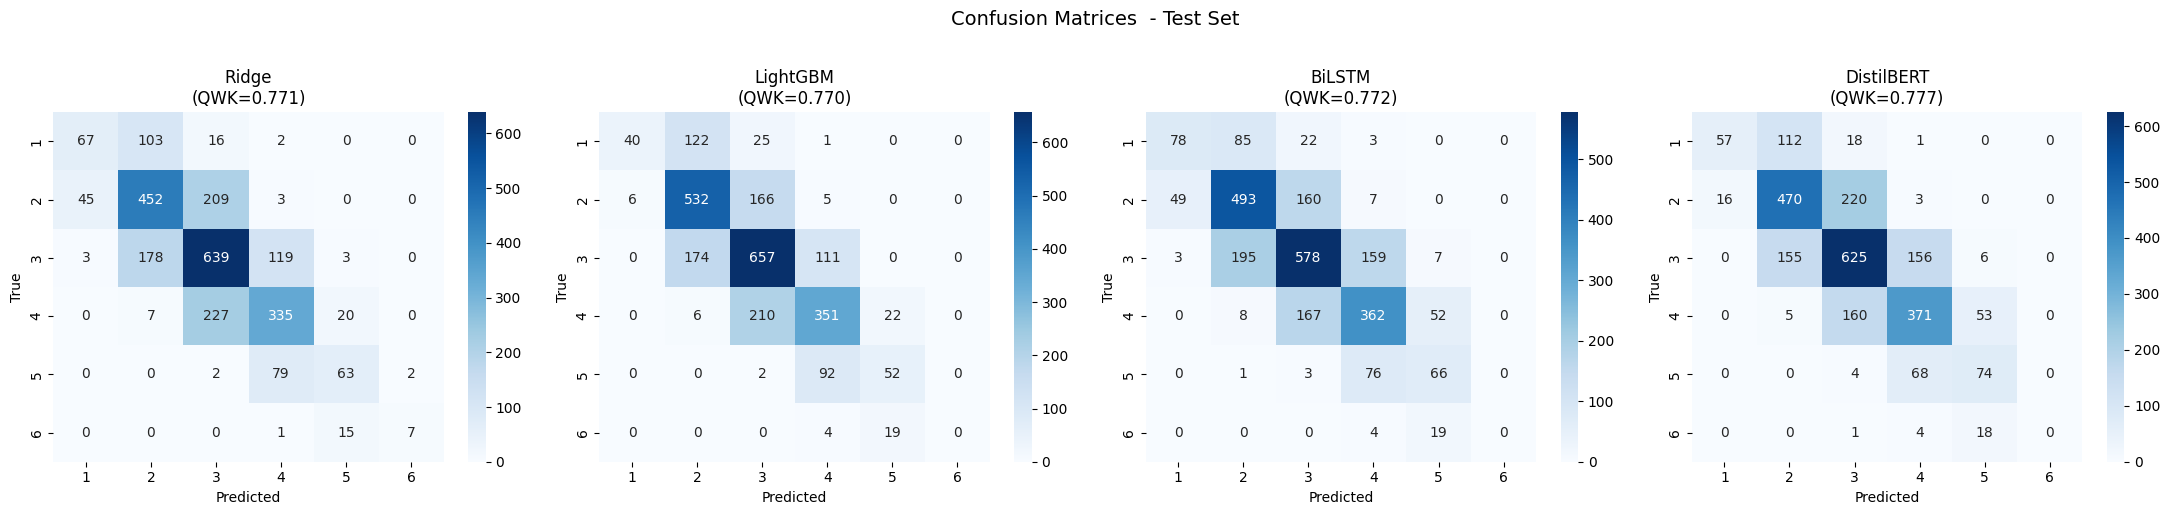

In [ ]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
score_labels = list(range(1, 7))

for i, (name, preds) in enumerate(all_test_preds.items()):
    preds_rounded = np.clip(np.round(preds), 1, 6).astype(int)
    cm = confusion_matrix(y_test, preds_rounded, labels=score_labels)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=score_labels, yticklabels=score_labels)
    axes[i].set_title(f'{name}\n(QWK={results[name]["QWK"]:.3f})')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

plt.suptitle('Confusion Matrices  - Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Statistical Significance

I used paired bootstrap testing (10,000 iterations) to check whether the differences between models were statistically significant. For each pair of models, the test set was resampled with replacement and the QWK scores were compared.

In [ ]:
def paired_bootstrap_test(y_true, preds_a, preds_b, n_bootstrap=10000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y_true)

    qwk_a_obs = quadratic_weighted_kappa(y_true, preds_a)
    qwk_b_obs = quadratic_weighted_kappa(y_true, preds_b)
    delta_observed = qwk_a_obs - qwk_b_obs

    count = 0
    qwk_a_boots, qwk_b_boots = [], []

    for _ in range(n_bootstrap):
        idx = rng.choice(n, n, replace=True)
        qwk_a = quadratic_weighted_kappa(y_true[idx], preds_a[idx])
        qwk_b = quadratic_weighted_kappa(y_true[idx], preds_b[idx])
        qwk_a_boots.append(qwk_a)
        qwk_b_boots.append(qwk_b)
        if (qwk_a - qwk_b) <= 0:
            count += 1

    p_value = count / n_bootstrap
    ci_a = (np.percentile(qwk_a_boots, 2.5), np.percentile(qwk_a_boots, 97.5))
    ci_b = (np.percentile(qwk_b_boots, 2.5), np.percentile(qwk_b_boots, 97.5))

    return delta_observed, p_value, ci_a, ci_b

In [ ]:
comparisons = [
    ('DistilBERT', 'Ridge'),
    ('DistilBERT', 'LightGBM'),
    ('DistilBERT', 'BiLSTM'),
    ('LightGBM', 'Ridge'),
]

bootstrap_results = {}
for model_a, model_b in comparisons:
    delta, p_val, ci_a, ci_b = paired_bootstrap_test(
        y_test, all_test_preds[model_a], all_test_preds[model_b]
    )
    bootstrap_results[(model_a, model_b)] = (delta, p_val, ci_a, ci_b)

    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
    print(f"{model_a} vs {model_b}: delta QWK = {delta:+.4f}, p = {p_val:.4f} ({sig})")
    print(f"  {model_a} 95% CI: [{ci_a[0]:.4f}, {ci_a[1]:.4f}]")
    print(f"  {model_b} 95% CI: [{ci_b[0]:.4f}, {ci_b[1]:.4f}]")
    print()

DistilBERT vs Ridge: delta QWK = +0.0055, p = 0.2247 (n.s.)
  DistilBERT 95% CI: [0.7607, 0.7916]
  Ridge 95% CI: [0.7542, 0.7868]

DistilBERT vs LightGBM: delta QWK = +0.0066, p = 0.1620 (n.s.)
  DistilBERT 95% CI: [0.7607, 0.7916]
  LightGBM 95% CI: [0.7538, 0.7852]

DistilBERT vs BiLSTM: delta QWK = +0.0049, p = 0.2283 (n.s.)
  DistilBERT 95% CI: [0.7607, 0.7916]
  BiLSTM 95% CI: [0.7551, 0.7875]

LightGBM vs Ridge: delta QWK = -0.0011, p = 0.5561 (n.s.)
  LightGBM 95% CI: [0.7538, 0.7852]
  Ridge 95% CI: [0.7542, 0.7868]



Rare classes (1, 5, 6) were harder to predict correctly due to fewer training examples, so I also broke down the MAE by score level.

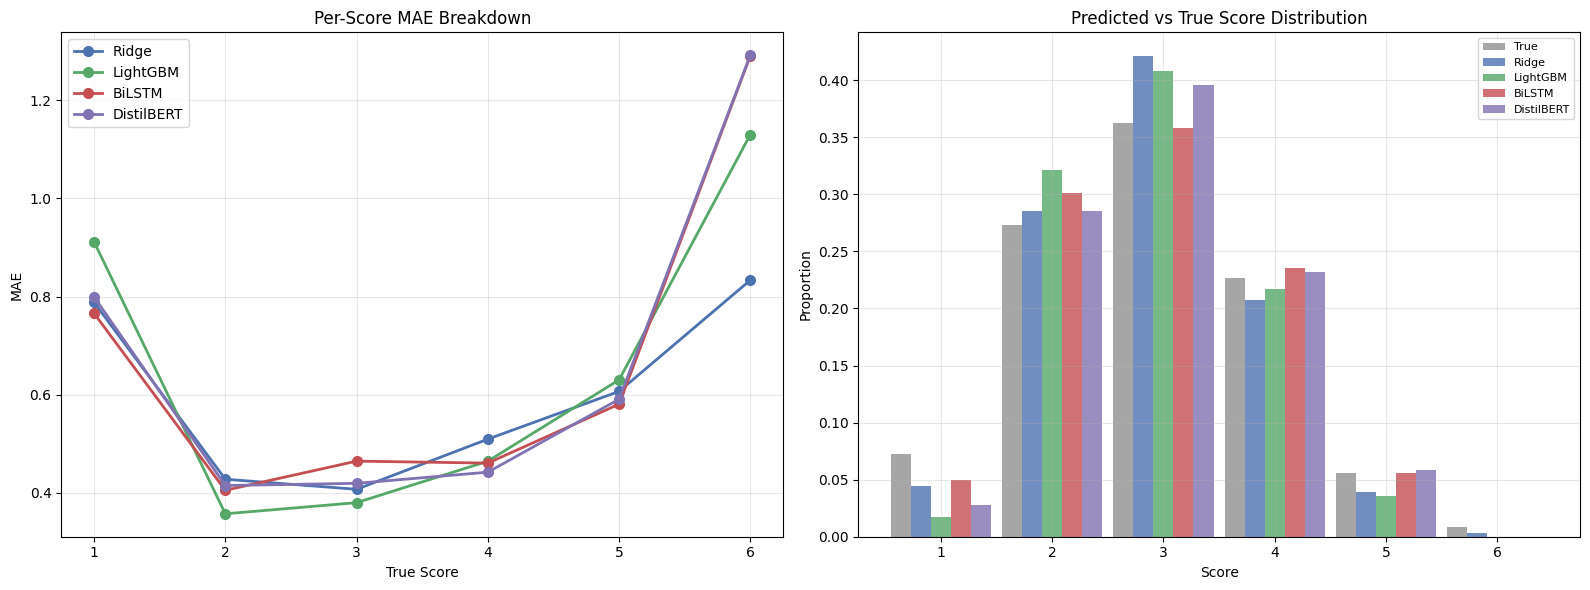

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

score_mae = {name: [] for name in model_names}
for score in range(1, 7):
    mask = y_test == score
    for name in model_names:
        if mask.sum() > 0:
            mae = mean_absolute_error(y_test[mask], all_test_preds[name][mask])
        else:
            mae = 0
        score_mae[name].append(mae)

for name, color in zip(model_names, colors):
    axes[0].plot(range(1, 7), score_mae[name], 'o-', label=name, color=color, linewidth=2, markersize=7)

axes[0].set_xlabel('True Score')
axes[0].set_ylabel('MAE')
axes[0].set_title('Per-Score MAE Breakdown')
axes[0].set_xticks(range(1, 7))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

width = 0.18
x = np.arange(1, 7)

true_counts = np.bincount(y_test, minlength=7)[1:]
true_pct = true_counts / true_counts.sum()
axes[1].bar(x - 2*width, true_pct, width, label='True', color='gray', alpha=0.7)

for j, (name, color) in enumerate(zip(model_names, colors)):
    pred_rounded = np.clip(np.round(all_test_preds[name]), 1, 6).astype(int)
    pred_counts = np.bincount(pred_rounded, minlength=7)[1:]
    pred_pct = pred_counts / pred_counts.sum()
    axes[1].bar(x + (j-1)*width, pred_pct, width, label=name, color=color, alpha=0.8)

axes[1].set_xlabel('Score')
axes[1].set_ylabel('Proportion')
axes[1].set_title('Predicted vs True Score Distribution')
axes[1].set_xticks(range(1, 7))
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Conclusion

I compared four models for automated essay scoring on 17,307 student essays scored 1 to 6. Ridge Regression and LightGBM used TF-IDF and hand-crafted features, BiLSTM used GloVe embeddings with a learned attention mechanism, and DistilBERT used pretrained transformer representations. All four models achieved similar QWK scores on the test set, and the paired bootstrap tests showed no statistically significant differences between them. Classical ML with good features is competitive with deep learning for this task and dataset size.

In [ ]:
results_df.round(4)

,QWK,MAE,RMSE,Spearman_rho
Ridge,0.7710,0.4786,0.6030,0.8097
LightGBM,0.7699,0.4522,0.5797,0.8288
BiLSTM,0.7716,0.4832,0.6208,0.8091
DistilBERT,0.7765,0.4682,0.5983,0.8223
